# NCF Hyperparameter Tuning

## 1. Setup

### 1.1. Imports

In [2]:
import sys
sys.path.insert(0, '..')

import json
import pickle
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from src.data.loader import load_ratings
from src.data.splitter import split_temporal
from src.data.adapter import DataAdapter
from src.models.ncf import NeuralCF
from src.evaluation.metrics import compute_ranking_metrics

### 1.2 Load and split data

In [3]:
ratings = load_ratings()

train_df, val_df, test_df = split_temporal(
    ratings,
    train_ratio=0.7,
    validation_ratio=0.15,
    test_ratio=0.15,
)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# Convert to IMPLICIT feedback (rating >= 4 = positive interaction)
adapter = DataAdapter()
train_data = adapter.to_implicit(train_df, threshold=4.0)

print(f"Positive interactions in training: {train_data.X_ui.nnz:,}")

Loaded 1000209 ratings from /content/ucu-recsys/data/ml-1m/ratings.dat
Train: 700,118 | Val: 150,081 | Test: 150,010
Positive interactions in training: 416,338


## 2. Tuning

### 2.1 Grid search parameters

In [4]:
param_grid = {
    'n_factors': [8, 16, 32],
    'layer_sizes': [[16, 8, 4], [32, 16, 8]],
    'n_epochs': [10, 25],
    'learning_rate': [0.001, 0.005],
}

# Generate all combinations
param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(product(*param_values))

print(f"Total combinations to try: {len(all_combinations)}")

Total combinations to try: 24


### 2.2 Grid search

In [5]:
results = []

# Only evaluate against positive validation interactions
val_positive = val_df[val_df['rating'] >= 4]
all_val_users = val_positive['user_id'].unique()

# Sample eval users for speed — NCF's TF1 session-based predict is slow per-user
np.random.seed(42)
n_eval_users = min(1000, len(all_val_users))
val_users = np.random.choice(all_val_users, size=n_eval_users, replace=False)
val_positive_sampled = val_positive[val_positive['user_id'].isin(val_users)]

print(f"Evaluating on {len(val_positive_sampled):,} positive interactions from {len(val_users):,} users (sampled from {len(all_val_users):,})")

for combo in tqdm(all_combinations, desc="Grid Search"):
    params = dict(zip(param_names, combo))

    model = NeuralCF(
        model_type="NeuMF",
        n_factors=params['n_factors'],
        layer_sizes=params['layer_sizes'],
        n_epochs=params['n_epochs'],
        learning_rate=params['learning_rate'],
        batch_size=2048,
        seed=42,
    )

    start_time = time.time()
    model.fit(train_data)
    train_time = time.time() - start_time

    # Generate recommendations for ranking eval
    recommendations = model.recommend_for_eval(val_users, k=10)
    val_ranking = compute_ranking_metrics(val_positive_sampled, recommendations, top_k=10)

    # Store layer_sizes as string for DataFrame compatibility
    result = {
        'n_factors': params['n_factors'],
        'layer_sizes': str(params['layer_sizes']),
        'n_epochs': params['n_epochs'],
        'learning_rate': params['learning_rate'],
        'val_ndcg': val_ranking['ndcg'],
        'val_recall': val_ranking['recall'],
        'train_time_sec': train_time,
    }
    results.append(result)

    print(f"{params} -> NDCG: {val_ranking['ndcg']:.4f} ({train_time:.1f}s)")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_ndcg', ascending=False)
results_df.head(10)

Evaluating on 13,294 positive interactions from 1,000 users (sampled from 5,927)


Grid Search:   0%|          | 0/24 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
Grid Search:   4%|▍         | 1/24 [04:41<1:48:04, 281.94s/it]

{'n_factors': 8, 'layer_sizes': [16, 8, 4], 'n_epochs': 10, 'learning_rate': 0.001} -> NDCG: 0.0983 (277.8s)


/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
Grid Search:   8%|▊         | 2/24 [09:27<1:44:07, 283.99s/it]

{'n_factors': 8, 'layer_sizes': [16, 8, 4], 'n_epochs': 10, 'learning_rate': 0.005} -> NDCG: 0.0982 (281.2s)


...

/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
Grid Search:  96%|█████████▌| 23/24 [3:06:03<08:26, 506.04s/it]

{'n_factors': 32, 'layer_sizes': [32, 16, 8], 'n_epochs': 25, 'learning_rate': 0.001} -> NDCG: 0.0904 (696.0s)


/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
Grid Search: 100%|██████████| 24/24 [3:17:44<00:00, 494.36s/it]

{'n_factors': 32, 'layer_sizes': [32, 16, 8], 'n_epochs': 25, 'learning_rate': 0.005} -> NDCG: 0.0856 (697.3s)


,n_factors,layer_sizes,n_epochs,learning_rate,val_ndcg,val_recall,train_time_sec
12,16,"[32, 16, 8]",10,0.001,0.100953,0.084047,282.560798
3,8,"[16, 8, 4]",25,0.005,0.100447,0.082467,695.003482
5,8,"[32, 16, 8]",10,0.005,0.099327,0.082294,282.161294
0,8,"[16, 8, 4]",10,0.001,0.098340,0.080275,277.750664
8,16,"[16, 8, 4]",10,0.001,0.098270,0.080299,283.089690
1,8,"[16, 8, 4]",10,0.005,0.098164,0.080961,281.197707
20,32,"[32, 16, 8]",10,0.001,0.097216,0.082522,280.324614
10,16,"[16, 8, 4]",25,0.001,0.097126,0.083383,701.545485
14,16,"[32, 16, 8]",25,0.001,0.096988,0.084160,699.955182
2,8,"[16, 8, 4]",25,0.001,0.096932,0.076115,695.868399


In [6]:
# Best parameters (by NDCG)
best_row = results_df.iloc[0]
best_params = {
    'n_factors': int(best_row['n_factors']),
    'layer_sizes': eval(best_row['layer_sizes']),
    'n_epochs': int(best_row['n_epochs']),
    'learning_rate': float(best_row['learning_rate']),
}

print("Best parameters:")
print(json.dumps(best_params, indent=2))
print(f"\nValidation NDCG@10: {best_row['val_ndcg']:.4f}")
print(f"Validation Recall@10: {best_row['val_recall']:.4f}")

Best parameters:
{
  "n_factors": 16,
  "layer_sizes": [
    32,
    16,
    8
  ],
  "n_epochs": 10,
  "learning_rate": 0.001
}

Validation NDCG@10: 0.1010
Validation Recall@10: 0.0840


## 3. Retrain best model

### 3.1 Retrain best model on train+val, evaluate on test

In [7]:
# Combine train and validation for final model
train_val_df = pd.concat([train_df, val_df], ignore_index=True)
train_val_data = adapter.to_implicit(train_val_df, threshold=4.0)

# Train final model
final_model = NeuralCF(model_type="NeuMF", **best_params, seed=42)
final_model.fit(train_val_data)

# Ranking eval (NDCG, etc.) - only on positive test interactions
test_positive = test_df[test_df['rating'] >= 4]
test_users = test_positive['user_id'].unique()
recommendations = final_model.recommend_for_eval(test_users, k=10)
ranking_metrics = compute_ranking_metrics(test_positive, recommendations, top_k=10)

print(f"Test NDCG@10: {ranking_metrics['ndcg']:.4f}")
print(f"Test MAP@10: {ranking_metrics['map']:.4f}")
print(f"Test Precision@10: {ranking_metrics['precision']:.4f}")
print(f"Test Recall@10: {ranking_metrics['recall']:.4f}")

/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '


Test NDCG@10: 0.1099
Test MAP@10: 0.0549
Test Precision@10: 0.0855
Test Recall@10: 0.0858


### 3.2 Save best model and results

In [ ]:
artifacts_dir = Path('../artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save parameters
params_to_save = {
    'best_params': best_params,
    'val_ndcg': float(best_row['val_ndcg']),
    'test_ranking_metrics': ranking_metrics,
}
with open(artifacts_dir / 'ncf_params.json', 'w') as f:
    json.dump(params_to_save, f, indent=2)
print(f"Parameters saved to {artifacts_dir / 'ncf_params.json'}")

# Save full results
results_df.to_csv(artifacts_dir / 'ncf_grid_search.csv', index=False)
print(f"Grid search results saved to {artifacts_dir / 'ncf_grid_search.csv'}")

### 3.3 Visualize results

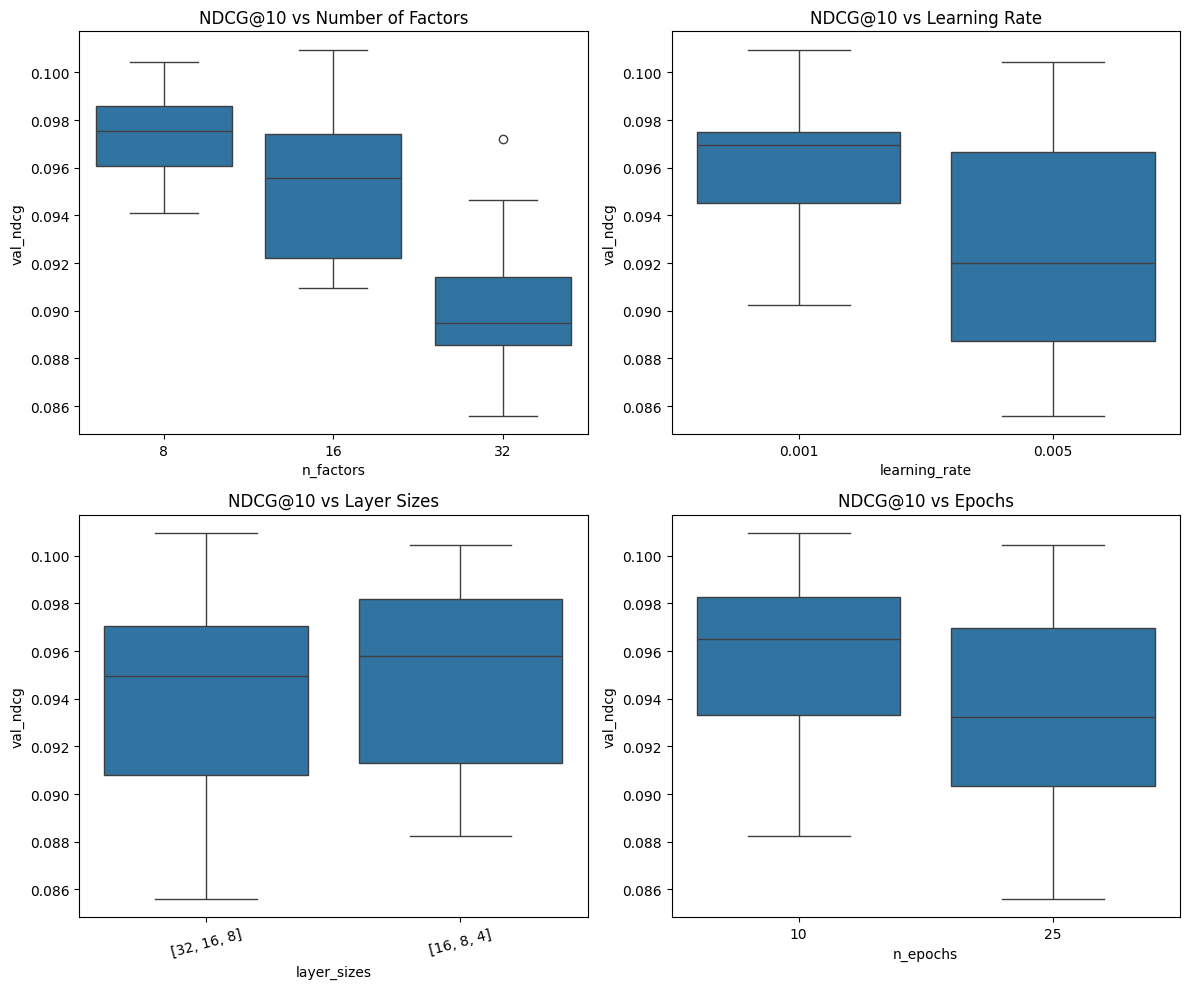

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# NDCG vs n_factors
ax = axes[0, 0]
sns.boxplot(data=results_df, x='n_factors', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Number of Factors')

# NDCG vs learning rate
ax = axes[0, 1]
sns.boxplot(data=results_df, x='learning_rate', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Learning Rate')

# NDCG vs layer_sizes
ax = axes[1, 0]
sns.boxplot(data=results_df, x='layer_sizes', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Layer Sizes')
ax.tick_params(axis='x', rotation=15)

# NDCG vs epochs
ax = axes[1, 1]
sns.boxplot(data=results_df, x='n_epochs', y='val_ndcg', ax=ax)
ax.set_title('NDCG@10 vs Epochs')

plt.tight_layout()
plt.savefig(artifacts_dir / 'ncf_tuning_plots.png', dpi=150)
plt.show()